# One-Dimensional Lattice Geometry

This notebook follows the construction chain from a direct lattice to a sampled first Brillouin zone.

```mermaid
flowchart TD
    D["DirectLattice1D"] --> W["WignerSeitzCell1D"]
    D --> R["ReciprocalLattice1D"]
    R --> B["FirstBrillouinZone1D"]
    B --> K["KPointPath1D"]
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from physkit.periodic import (
    DirectLattice,
    DirectLattice1D,
    FirstBrillouinZone1D,
    KPointPath1D,
    ReciprocalLattice1D,
    WignerSeitzCell1D,
)

## Direct lattice 1D ('DirectLattice1D`)

The primitive basis contains one vector $a_1=a$. Direct-lattice translations are

$$R_n=na.$$

In [2]:
a = 1.0
direct_lattice = DirectLattice1D(lattice_constant=a)
assert isinstance(direct_lattice, DirectLattice)

cell_indices = np.arange(-4, 5)
direct_points = np.array([
    direct_lattice.translation(index)
    for index in cell_indices
])

print("Primitive basis A:")
print(direct_lattice.primitive_basis)
print("Primitive-cell length:", direct_lattice.measure)

Primitive basis A:
[[1.]]
Primitive-cell length: 1.0


## Wigner--Seitz cell

The Wigner--Seitz cell contains points closer to $R=0$ than to any other direct-lattice point:

$$\mathcal W=[-a/2,+a/2].$$

In [3]:
wigner_seitz_cell = WignerSeitzCell1D(
    lattice=direct_lattice,
)

print("Wigner-Seitz interval:", (wigner_seitz_cell.lower, wigner_seitz_cell.upper))
print("Wigner-Seitz length:", wigner_seitz_cell.measure)

assert np.isclose(
    wigner_seitz_cell.measure,
    direct_lattice.measure,
)

Wigner-Seitz interval: (-0.5, 0.5)
Wigner-Seitz length: 1.0


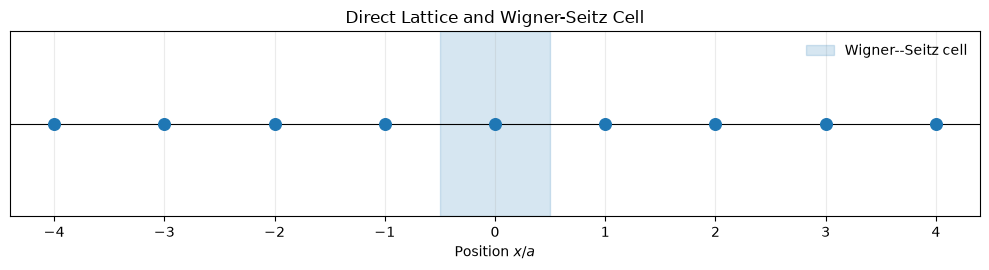

In [4]:
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.scatter(direct_points / a, np.zeros_like(direct_points), s=70, color="tab:blue", zorder=3)
ax.axvspan(
    wigner_seitz_cell.lower / a,
    wigner_seitz_cell.upper / a,
    color="tab:blue",
    alpha=0.18,
    label="Wigner--Seitz cell",
)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel(r"Position $x/a$")
ax.set_yticks([])
ax.set_ylim(-0.15, 0.15)
ax.set_title("Direct Lattice and Wigner-Seitz Cell")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Reciprocal lattice 1D

The reciprocal primitive basis is derived from the direct basis:

$$B=2\pi A^{-\mathsf T}.$$

In one dimension, $b_1=2\pi/a$.

In [5]:
reciprocal_lattice = ReciprocalLattice1D.from_direct_lattice(
    direct_lattice=direct_lattice
)
isinstance(reciprocal_lattice, ReciprocalLattice1D)


print("Reciprocal primitive basis B:")
print(reciprocal_lattice.primitive_basis)
print("b_1:", reciprocal_lattice.b1)

assert np.allclose(
    direct_lattice.primitive_basis.T
    @ reciprocal_lattice.primitive_basis,
    2.0 * np.pi * np.eye(1),
)

reciprocal_lattice_2 = ReciprocalLattice1D(b1=reciprocal_lattice.b1)
assert np.allclose(reciprocal_lattice.b1, reciprocal_lattice_2.b1)

Reciprocal primitive basis B:
[[6.28318531]]
b_1: 6.283185307179586


## First Brillouin zone

The first Brillouin zone is the Wigner--Seitz cell of the reciprocal lattice:

$$
\mathcal B_1 
= \left[
  -\frac{b_1}{2},
  +\frac{b_1}{2}
\right]
$$

In [7]:
first_brillouin_zone = FirstBrillouinZone1D(
    reciprocal_lattice=reciprocal_lattice,
)

print("First Brillouin zone:", (first_brillouin_zone.lower, first_brillouin_zone.upper))
print("Zone length:", first_brillouin_zone.measure)

assert np.isclose(
    first_brillouin_zone.measure,
    (2.0 * np.pi) / direct_lattice.measure,
)

First Brillouin zone: (-3.141592653589793, 3.141592653589793)
Zone length: 6.283185307179586


## $k$-point path

A path is a numerical sampling of the zone. It is separate from the zone geometry itself.

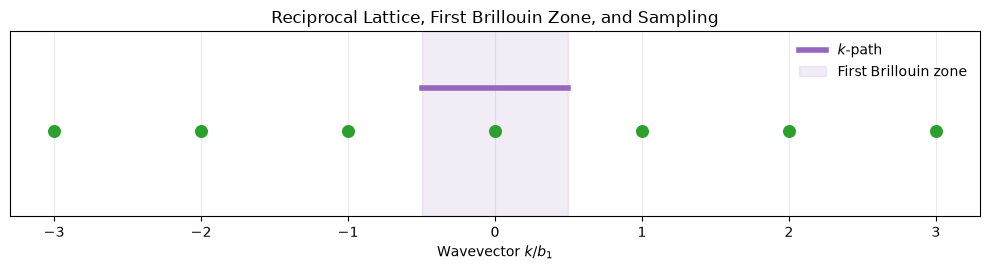

In [ ]:
k_path = KPointPath1D.from_first_brillouin_zone(
    zone=first_brillouin_zone,
    number_of_points=301,
    endpoint=True,
)

fig, ax = plt.subplots(figsize=(10, 2.8))
reciprocal_modes = np.arange(-3, 4)
reciprocal_points = reciprocal_lattice.vector(reciprocal_modes)
ax.scatter(
    reciprocal_points / reciprocal_lattice.b1, 
    np.zeros_like(reciprocal_points), 
    s=70, 
    color="tab:green", 
    zorder=3)
ax.plot(
    k_path.values / reciprocal_lattice.b1, 
    np.full(k_path.size, 0.06), 
    color="tab:purple", 
    linewidth=4.0, 
    label=r"$k$-path")
ax.axvspan(
    xmin=-0.5, xmax=0.5, 
    color="tab:purple", 
    alpha=0.12, 
    label="First Brillouin zone")
ax.set_xlabel(r"Wavevector $k/b_1$")
ax.set_yticks([])
ax.set_ylim(-0.12, 0.14)
ax.set_title("Reciprocal Lattice, First Brillouin Zone, and Sampling")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Summary

$$
\text{Direct lattice}
\longrightarrow
\text{Wigner--Seitz cell}.
$$

$$
\text{Direct lattice}
\longrightarrow
\text{reciprocal lattice}
\longrightarrow
\text{first Brillouin zone}
\longrightarrow
\text{$k$-point path}.
$$

2026, Eugene Joseph M. Ragasa